# Notebook 05 - Text Analysis 

In this notebook we make statiscal analises on the text distributions plotted in notebook ```03_textual_visualization.ipynb``` and find the best fit for this distributions. 

## 0. Setup

In [491]:
# Libraries

# General
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis
from scipy import stats

# Plotting Options
from matplotlib import pyplot as plt                           # imports the Pyplot module from the Matplotlib library for plotting
import seaborn as sns 
plt.rcParams['text.usetex'] = True                             # enables LaTeX rendering for text in plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # LaTeX preamble

# File management
from pathlib import Path                  # imports path tools from Pathlib for working with file paths
import os                               # imports the OS library for interacting with the operating system

def find_project_root(start=Path.cwd(), marker='data'): # defines a function to find the project root directory by looking for a specific marker (default is 'data')
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

from tools import text_tools # tools for text processing
from tools import dataframe_tools as dftools # tools for dataframe processing

In [492]:
biblio = text_tools.bibliography()  # defines a bibliography object
print( biblio.files )               # lists the files in the directory

['dreams_in_the_witch.txt', 'ex_oblivione.txt', 'poetry_of_gods.txt', 'doorstep.txt', 'colour_out_of_space.txt', 'iranon.txt', 'street.txt', 'arthur_jermyn.txt', 'crawling_chaos.txt', 'ulthar.txt', 'azathoth.txt', 'shadow_out_of_time.txt', 'haunter.txt', 'martins_beach.txt', 'tree.txt', 'whisperer.txt', 'moon_bog.txt', 'unnamable.txt', 'beast.txt', 'alchemist.txt', 'terrible_old_man.txt', 'nameless.txt', 'reanimator.txt', 'celephais.txt', 'gates_of_silver_key.txt', 'medusas_coil.txt', 'dagon.txt', 'picture_house.txt', 'memory.txt', 'white_ship.txt', 'erich_zann.txt', 'tomb.txt', 'temple.txt', 'he.txt', 'pickman.txt', 'silver_key.txt', 'clergyman.txt', 'old_folk.txt', 'from_beyond.txt', 'descendent.txt', 'nyarlathotep.txt', 'vault.txt', 'hypnos.txt', 'polaris.txt', 'book.txt', 'shunned_house.txt', 'pharoahs.txt', 'randolph_carter.txt', 'innsmouth.txt', 'charles_dexter_ward.txt', 'dunwich.txt', 'festival.txt', 'other_gods.txt', 'redhook.txt', 'hound.txt', 'outsider.txt', 'mountains_of_ma

## 1.1. Vocabulary to word analysis

Here we perform a statiscal analysis and curve fitting for the vocabulary to word distribution

In [493]:
vocab_to_word = biblio.df_texts['vocabulary']/biblio.df_texts['word_count']

In [494]:
text_tools.dist_statistics(vocab_to_word)

{'mean': 0.3939,
 'standard_deviation': 0.0852,
 'distribution_mode': 0.1857,
 'distribution_median': 0.3969,
 'distribution_skew': -0.1634,
 'distribution_kurt': 0.1238}

Possible candidates for this distributions are the distributions: gamma, beta, rayleigh, lognorm and chi2. Therefore we create a dictionary with each distribution and plot them below to visualize

/home/gabriel/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


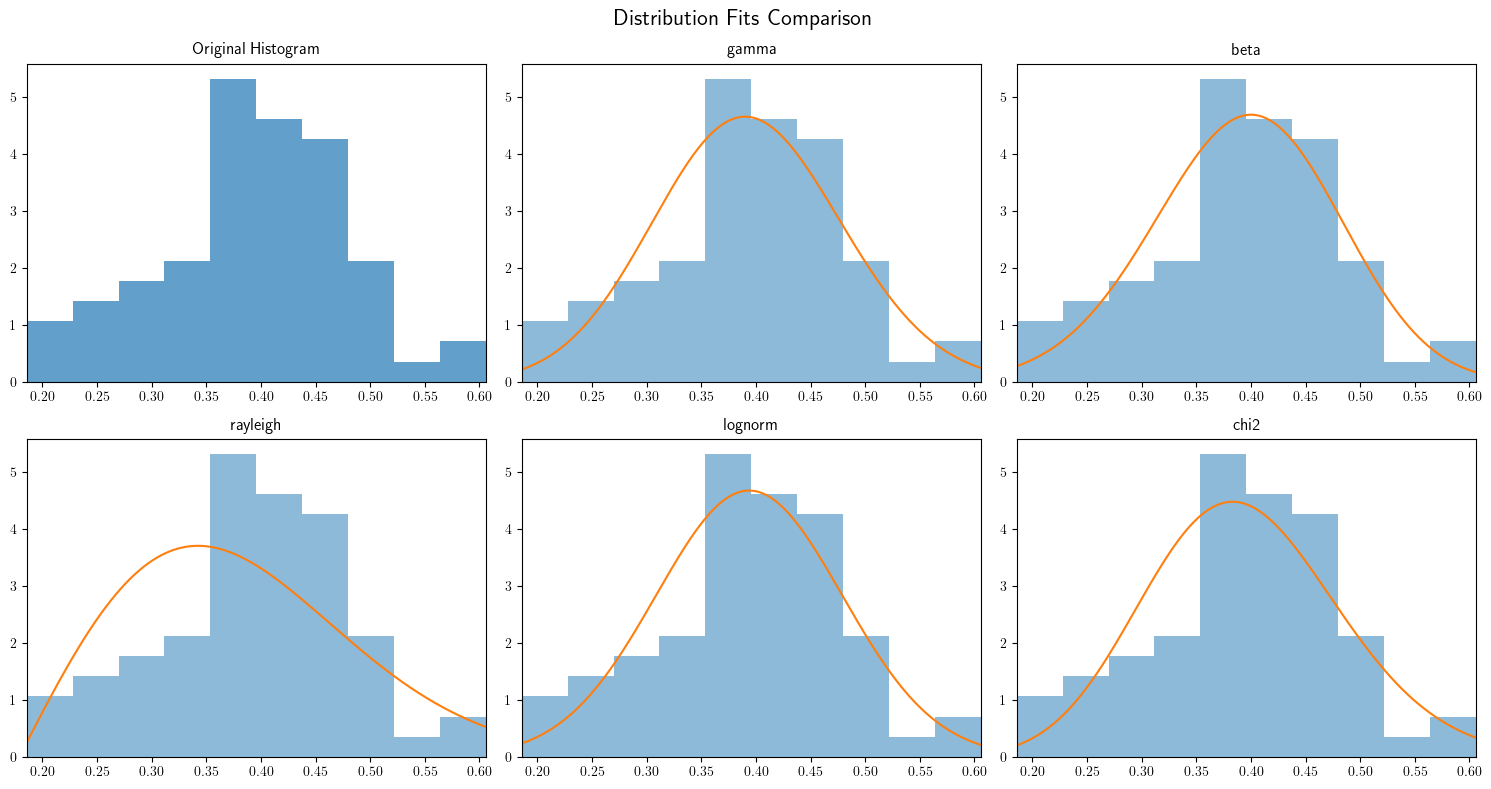

In [495]:
distributions = {
    "gamma": stats.gamma,
    "beta": stats.beta,
    "rayleigh": stats.rayleigh,
    "lognorm": stats.lognorm,
    "chi2": stats.chi2
}

# eixo comum
x = np.linspace(min(vocab_to_word), max(vocab_to_word), 1000)

# subplots (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

axes[0].hist(vocab_to_word, bins=10, density=True, alpha=0.7)
axes[0].set_title('Original Histogram')

for i, (name, dist) in enumerate(distributions.items(), start=1):
    ax = axes[i]
    
    # histograma
    ax.hist(vocab_to_word, bins=10, density=True, alpha=0.5)
    
    # fit
    params = dist.fit(vocab_to_word)
    pdf = dist.pdf(x, *params)
    
    # plot
    ax.plot(x, pdf)
    ax.set_title(name)

# ajuste geral
for ax in axes:
    ax.set_xlim(min(vocab_to_word), max(vocab_to_word))

plt.suptitle('Distribution Fits Comparison', fontsize=16)
plt.tight_layout()
plt.show()

Now we perform the fit using the Kolmogorov-Smirnov test

In [496]:
results = {}

for name, dist in distributions.items():
    # Fit dos parâmetros
    params = dist.fit(vocab_to_word)
    
    # Teste KS
    ks_stat, p_value = stats.kstest(vocab_to_word, name, args=params)
    
    results[name] = {
        "params": params,
        "ks_stat": ks_stat,
        "p_value": p_value
    }

# test cramer von mises

# shapiro wilk (gaussianity)
    

The results are

In [497]:
# Results 

for name, res in results.items():
    print(f"{name}: p-value = {res['p_value']:.4f}")

gamma: p-value = 0.7111
beta: p-value = 0.8535
rayleigh: p-value = 0.0219
lognorm: p-value = 0.7563
chi2: p-value = 0.7196


Since beta has the highets p-value, we compare it now with what we had

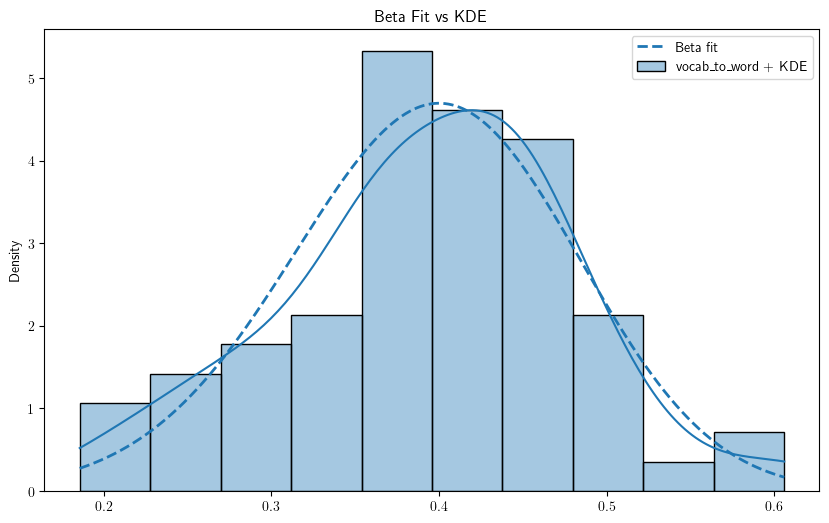

In [498]:
from scipy.stats import beta

# fit da beta
params = beta.fit(vocab_to_word)

# PDF da beta ajustada
beta_pdf = beta.pdf(x, *params)

# plot
plt.figure(figsize=(10, 6))

# histograma + KDE (seaborn)
sns.histplot(vocab_to_word, bins=10, stat='density', kde=True, alpha=0.4, label='vocab_to_word + KDE')

# beta ajustada
plt.plot(x, beta_pdf, label='Beta fit', linewidth=2, linestyle = 'dashed')

plt.title('Beta Fit vs KDE')
plt.legend()
plt.show()

## 1.2. Vocabulary to sentence analysis

Here we perform a statiscal analysis and curve fitting for the vocabulary to sentence distribution

In [499]:
vocabulary_to_sentence = biblio.df_texts['vocabulary']/biblio.df_texts['sentence_count']


Text(0.5, 1.0, 'Vocabulary to sentence count ratio distribution')

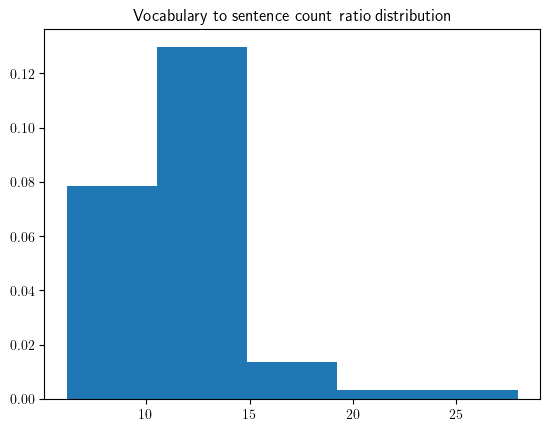

In [500]:
# vocabulary to sentence count 

vocabulary_to_sentence = biblio.df_texts['vocabulary']/biblio.df_texts['sentence_count']

plt.hist(vocabulary_to_sentence, density=True, bins= 5)
plt.title('Vocabulary to sentence count ratio distribution') 

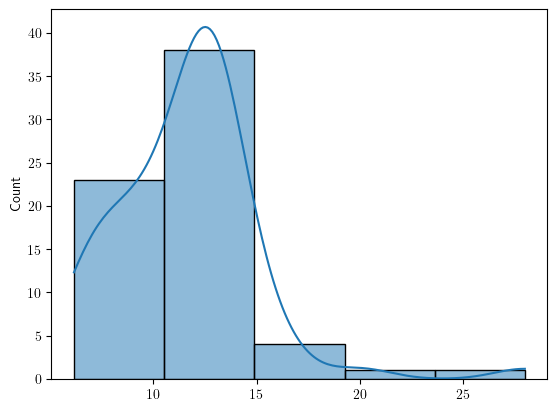

In [501]:
sns.histplot(vocabulary_to_sentence, kde= True, bins=5)
plt.show()

In [502]:
text_tools.dist_statistics(vocabulary_to_sentence)

{'mean': 11.6325,
 'standard_deviation': 3.41,
 'distribution_mode': 6.1455,
 'distribution_median': 12.2267,
 'distribution_skew': 1.5249,
 'distribution_kurt': 6.3084}

In [503]:
from scipy import stats

fits = {}

fits['expon'] = stats.expon.fit(vocabulary_to_sentence)
fits['gamma'] = stats.gamma.fit(vocabulary_to_sentence)
fits['lognorm'] = stats.lognorm.fit(vocabulary_to_sentence)
fits['weibull'] = stats.weibull_min.fit(vocabulary_to_sentence)

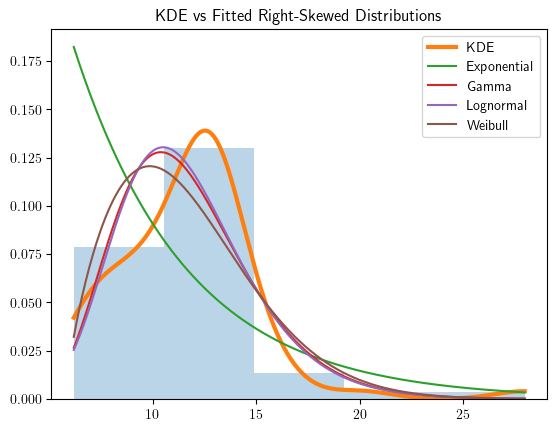

In [504]:
from scipy import stats

# Fit distributions
fits = {
    'Exponential': stats.expon.fit(vocabulary_to_sentence),
    'Gamma': stats.gamma.fit(vocabulary_to_sentence),
    'Lognormal': stats.lognorm.fit(vocabulary_to_sentence),
    'Weibull': stats.weibull_min.fit(vocabulary_to_sentence)
}

x = np.linspace(min(vocabulary_to_sentence), max(vocabulary_to_sentence), 500)

# KDE
kde = stats.gaussian_kde(vocabulary_to_sentence)
plt.hist(vocabulary_to_sentence, bins=5, density=True, alpha=0.3)
plt.plot(x, kde(x), label='KDE', linewidth=3)

# Overlay PDFs
for name, params in fits.items():
    if name == 'Weibull':
        dist = stats.weibull_min
    elif name == 'Lognormal':
        dist = stats.lognorm
    elif name == 'Gamma':
        dist = stats.gamma
    else:
        dist = stats.expon
    
    plt.plot(x, dist.pdf(x, *params), label=name)

plt.legend()
plt.title("KDE vs Fitted Right-Skewed Distributions")
plt.show()

Here is a better way to compare them

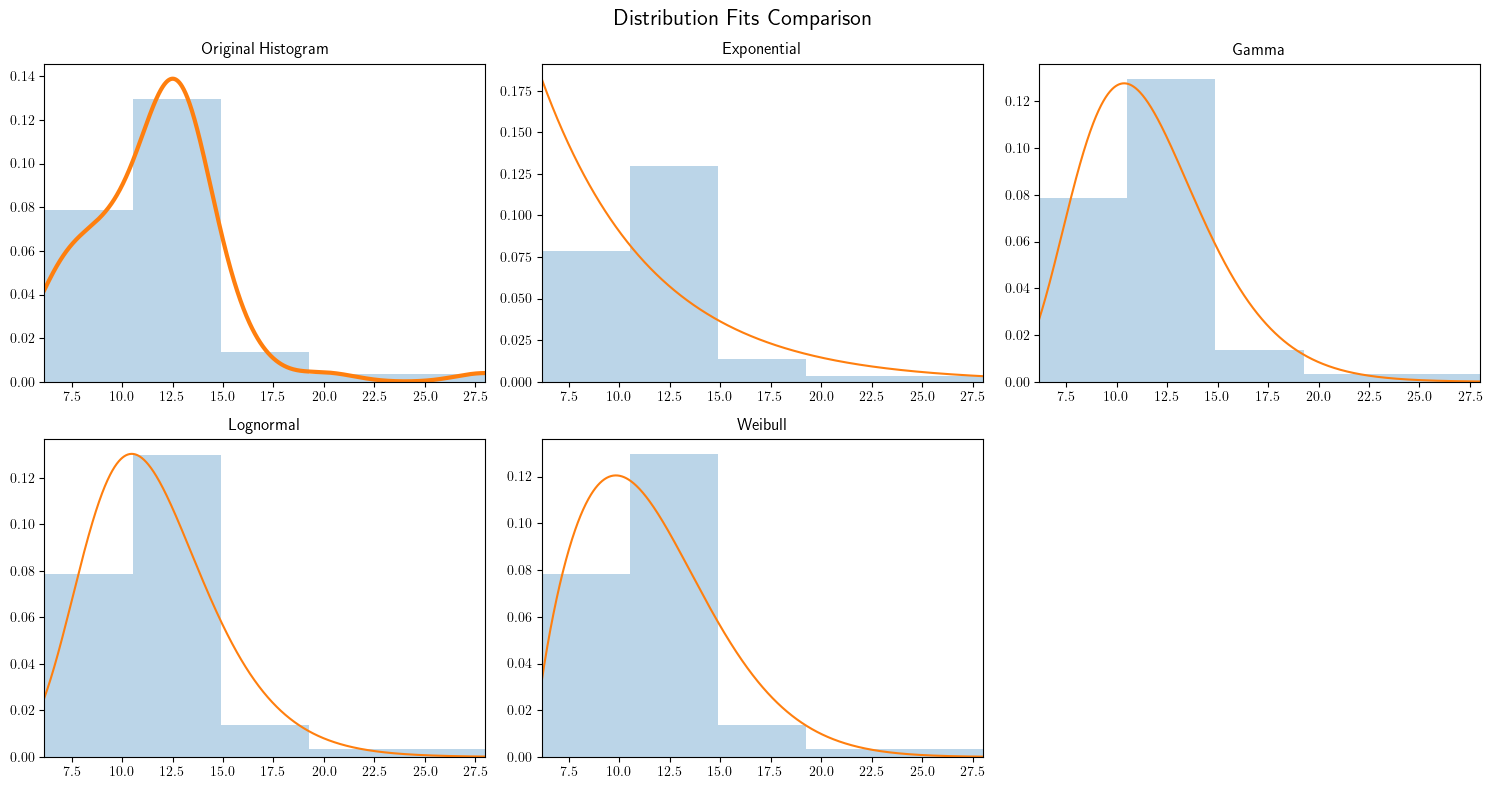

In [505]:
distributions = {
    'Exponential': stats.expon.fit(vocabulary_to_sentence),
    'Gamma': stats.gamma.fit(vocabulary_to_sentence),
    'Lognormal': stats.lognorm.fit(vocabulary_to_sentence),
    'Weibull': stats.weibull_min.fit(vocabulary_to_sentence)
}

# eixo comum
x = np.linspace(min(vocabulary_to_sentence), max(vocabulary_to_sentence), 1000)
kde = stats.gaussian_kde(vocabulary_to_sentence)

# subplots (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

axes[0].hist(vocabulary_to_sentence, bins=5, density=True, alpha=0.3)
axes[0].plot(x, kde(x), label='KDE', linewidth=3)
axes[0].set_title('Original Histogram')

for i, (name, params) in enumerate(distributions.items(), start =1):
    ax = axes[i]

    axes[i].hist(vocabulary_to_sentence, bins=5, density=True, alpha=0.3)

    if name == 'Weibull':
        dist = stats.weibull_min
    elif name == 'Lognormal':
        dist = stats.lognorm
    elif name == 'Gamma':
        dist = stats.gamma
    else:
        dist = stats.expon
    
    ax.plot(x, dist.pdf(x, *params), label=name)
    ax.set_title(name)

# ajuste geral
for ax in axes:
    ax.set_xlim(min(vocabulary_to_sentence), max(vocabulary_to_sentence))

axes[5].set_visible(False)

plt.suptitle('Distribution Fits Comparison', fontsize=16)
plt.tight_layout()
plt.show()

In [506]:
# from scipy.special import gamma as gamma_func  


# k = np.linspace(min(vocabulary_to_sentence), max(vocabulary_to_sentence), 1000)
# distribution_statistics = text_tools.dist_statistics(vocabulary_to_sentence)
# lambda_poisson = 12
# poisson = (lambda_poisson ** k)*(np.exp(-lambda_poisson))/gamma_func(k+1)


In [507]:

# # plot
# plt.figure(figsize=(10, 6))

# # histograma + KDE (seaborn)
# sns.histplot(vocabulary_to_sentence, bins=6, stat='density', kde=True, alpha=0.4, label='vocab_to_word + KDE')

# # poisson 

# plt.plot(k, poisson)

# plt.title('Beta Fit vs KDE')
# plt.legend()
# plt.show()

Visually, the the distributions that best fit out histogram are the Lognormal and the Gamma. Thus, we will perform a Kolmogorov–Smirnov (KS) test to check this

In [508]:
distributions = {
    'Exponential': stats.expon.fit(vocabulary_to_sentence),
    'Gamma': stats.gamma.fit(vocabulary_to_sentence),
    'Lognormal': stats.lognorm.fit(vocabulary_to_sentence),
    'Weibull': stats.weibull_min.fit(vocabulary_to_sentence)
}
results = {}

# Mapping from display names to scipy distribution names
dist_names = {
    'Exponential': 'expon',
    'Gamma': 'gamma',
    'Lognormal': 'lognorm',
    'Weibull': 'weibull_min'
}

for name, params in distributions.items():
    dist_name = dist_names[name]
    ks_stat, p_value = stats.kstest(vocabulary_to_sentence, dist_name, args=params)
    results[name] = {
        "params": params,
        "ks_stat": ks_stat,
        "p_value": p_value
    }

# Print the results
for name, res in results.items():
    print(f"{name}: p-value = {res['p_value']:.4f}")

Exponential: p-value = 0.0012
Gamma: p-value = 0.1820
Lognormal: p-value = 0.1783
Weibull: p-value = 0.1491


In [509]:
# from scipy.stats import beta
# from scipy.stats import gamma

# # fit da beta
# params_beta = beta.fit(vocabulary_to_sentence)
# params_gamma = gamma.fit(vocabulary_to_sentence)

# # PDF da beta ajustada
# beta_pdf = beta.pdf(k, *params_beta)

# # PDF da gamma

# gamma_pdf = gamma.pdf(k, *params_gamma)

# # plot
# plt.figure(figsize=(10, 6))

# # histograma + KDE (seaborn)
# sns.histplot(vocabulary_to_sentence, bins=20, stat='density', kde=True, alpha=0.4, label='vocab_to_word + KDE')

# # beta ajustada
# plt.plot(k, beta_pdf, label='Beta fit', linewidth=2, linestyle = 'dashed')
# plt.plot(k, gamma_pdf, label = 'Gamma fit', linewidth =2, linestyle = ':')

# plt.title('Beta Fit vs KDE')
# plt.legend()
# plt.show()

### Vocabulary to word distribution for each story 

## 1.1 Individual text analysis 

In this section we make the analysis for each individual text. The plots were made in the notebook $\tt 03\_textual\_visualization$, here we will just find the best fit for the distributions. 

### 1.1.1 The Call of Cthulhu

Using $\tt biblio.sentences$ which a dictionary where the key is the story name and the value is a list with every phrase on the text, we create a new list called $\tt cthulhu\_lens$ with the number of characters of every sentence in the story.

In [510]:
cthulhu_lens = [ len(phrase) for phrase in biblio.sentences['cthulhu'] ]
#cthulhu_lens_filtered = [length for length in cthulhu_lens if length > 43]
print(cthulhu_lens)

[419, 131, 126, 343, 127, 109, 145, 185, 139, 159, 199, 214, 72, 324, 224, 115, 218, 217, 139, 132, 333, 125, 228, 242, 153, 121, 181, 169, 81, 158, 152, 111, 35, 51, 56, 1, 1, 40, 181, 275, 112, 70, 202, 291, 185, 128, 153, 96, 194, 218, 242, 179, 130, 167, 176, 289, 95, 240, 124, 331, 181, 379, 90, 213, 158, 184, 127, 151, 224, 112, 156, 73, 150, 132, 190, 260, 164, 260, 172, 109, 295, 194, 148, 203, 151, 50, 192, 223, 62, 250, 198, 49, 112, 52, 115, 143, 106, 137, 236, 176, 186, 129, 100, 2, 188, 349, 143, 297, 251, 83, 153, 84, 94, 416, 303, 85, 301, 179, 174, 220, 207, 252, 156, 119, 176, 200, 221, 237, 287, 132, 386, 185, 294, 157, 117, 128, 179, 205, 234, 288, 164, 98, 220, 198, 128, 179, 262, 165, 141, 139, 264, 157, 141, 106, 288, 125, 247, 144, 49, 59, 230, 164, 156, 216, 228, 112, 129, 118, 115, 125, 336, 195, 208, 261, 18, 75, 220, 76, 185, 68, 223, 132, 88, 162, 186, 126, 127, 138, 177, 316, 110, 30, 55, 127, 37, 33, 103, 76, 82, 78, 114, 183, 71, 200, 148, 88, 127, 178, 8

In [511]:
print(min(cthulhu_lens))

1


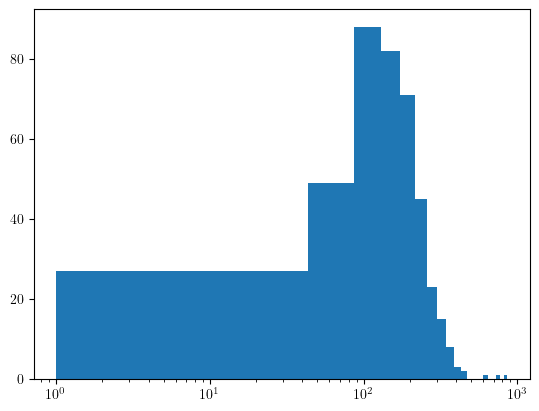

In [528]:
plt.hist(cthulhu_lens, bins = 20)
plt.xscale('log')

In [512]:
def statiscal_precision(story_lenght):
    N = len(story_lenght)
    sigma = round(1/(N**(1/2)),3)
    return sigma

In [513]:
statiscal_precision(cthulhu_lens)

0.049

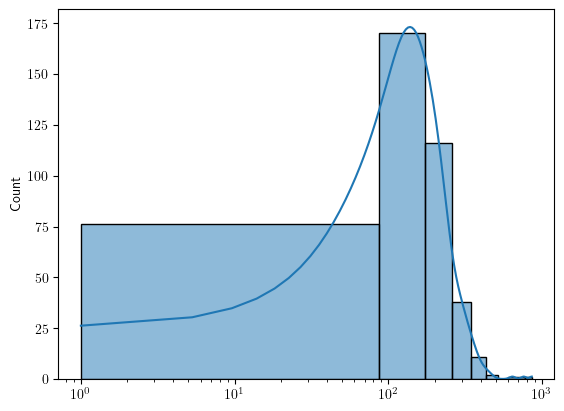

In [529]:
sns.histplot(cthulhu_lens,bins = 10, kde = True)
plt.xscale('log')


This is also right skewd so we use the same distributions as we did above

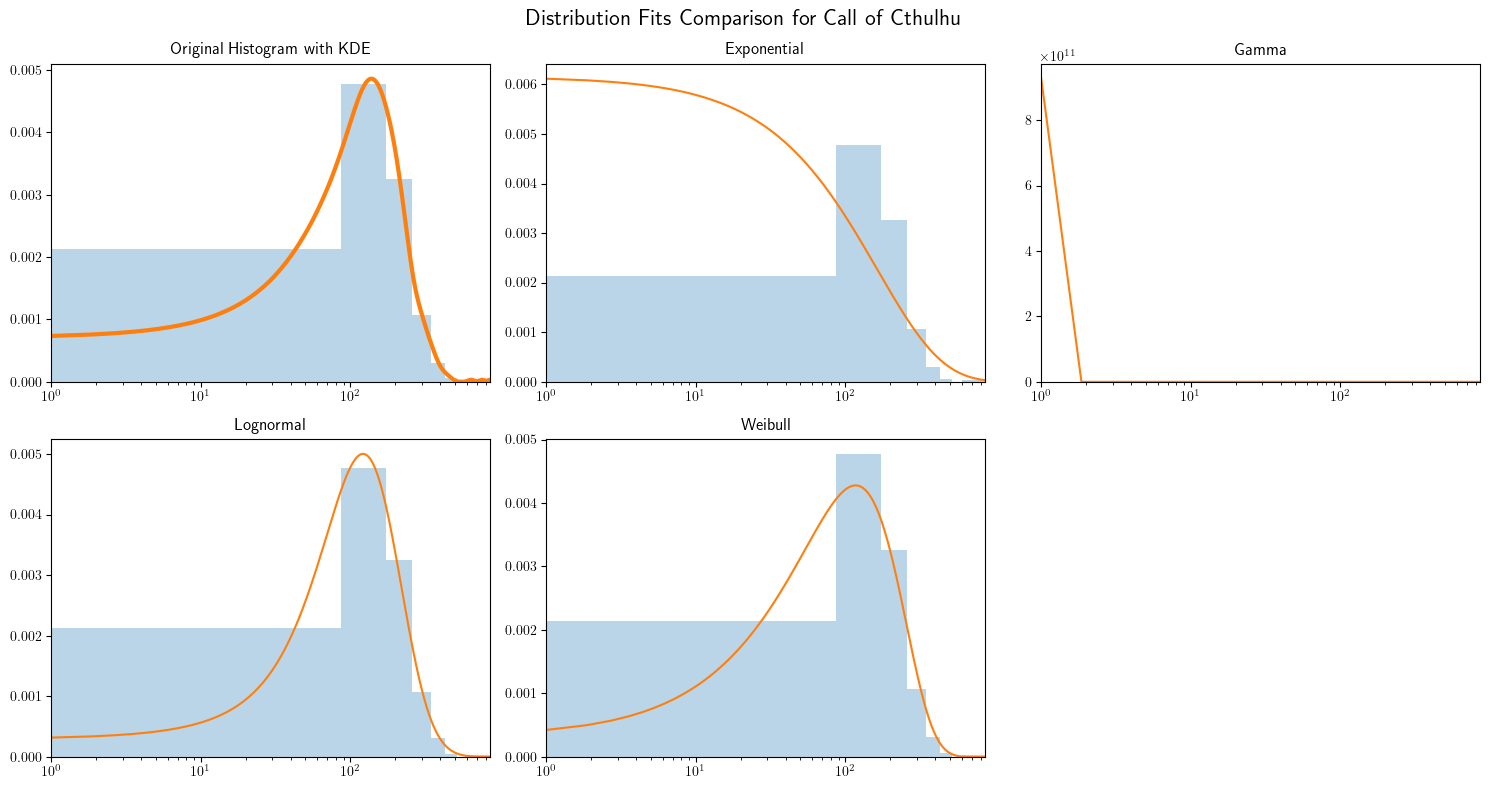

In [532]:
distributions = {
    'Exponential': stats.expon.fit(cthulhu_lens),
    'Gamma': stats.gamma.fit(cthulhu_lens),
    'Lognormal': stats.lognorm.fit(cthulhu_lens),
    'Weibull': stats.weibull_min.fit(cthulhu_lens)
}

# eixo comum
x = np.linspace(min(cthulhu_lens), max(cthulhu_lens), 1000)
kde = stats.gaussian_kde(cthulhu_lens)

# subplots (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

axes[0].hist(cthulhu_lens, bins=10, density=True, alpha=0.3)
axes[0].plot(x, kde(x), label='KDE', linewidth=3)
axes[0].set_title('Original Histogram with KDE')

for i, (name, params) in enumerate(distributions.items(), start =1):
    ax = axes[i]

    axes[i].hist(cthulhu_lens, bins=10, density=True, alpha=0.3)

    if name == 'Weibull':
        dist = stats.weibull_min
    elif name == 'Lognormal':
        dist = stats.lognorm
    elif name == 'Gamma':
        dist = stats.gamma
    else:
        dist = stats.expon
    
    ax.plot(x, dist.pdf(x, *params), label=name)
    ax.set_title(name)

# ajuste geral
for ax in axes:
    ax.set_xlim(min(cthulhu_lens), max(cthulhu_lens))
    ax.set_xscale('log')
axes[5].set_visible(False)

plt.suptitle('Distribution Fits Comparison for Call of Cthulhu', fontsize=16)
plt.tight_layout()
plt.show()

Now we can proceed to the curve fitting. One distribution that feels right for this histogram is the beta distribution. 

/home/gabriel/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/home/gabriel/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


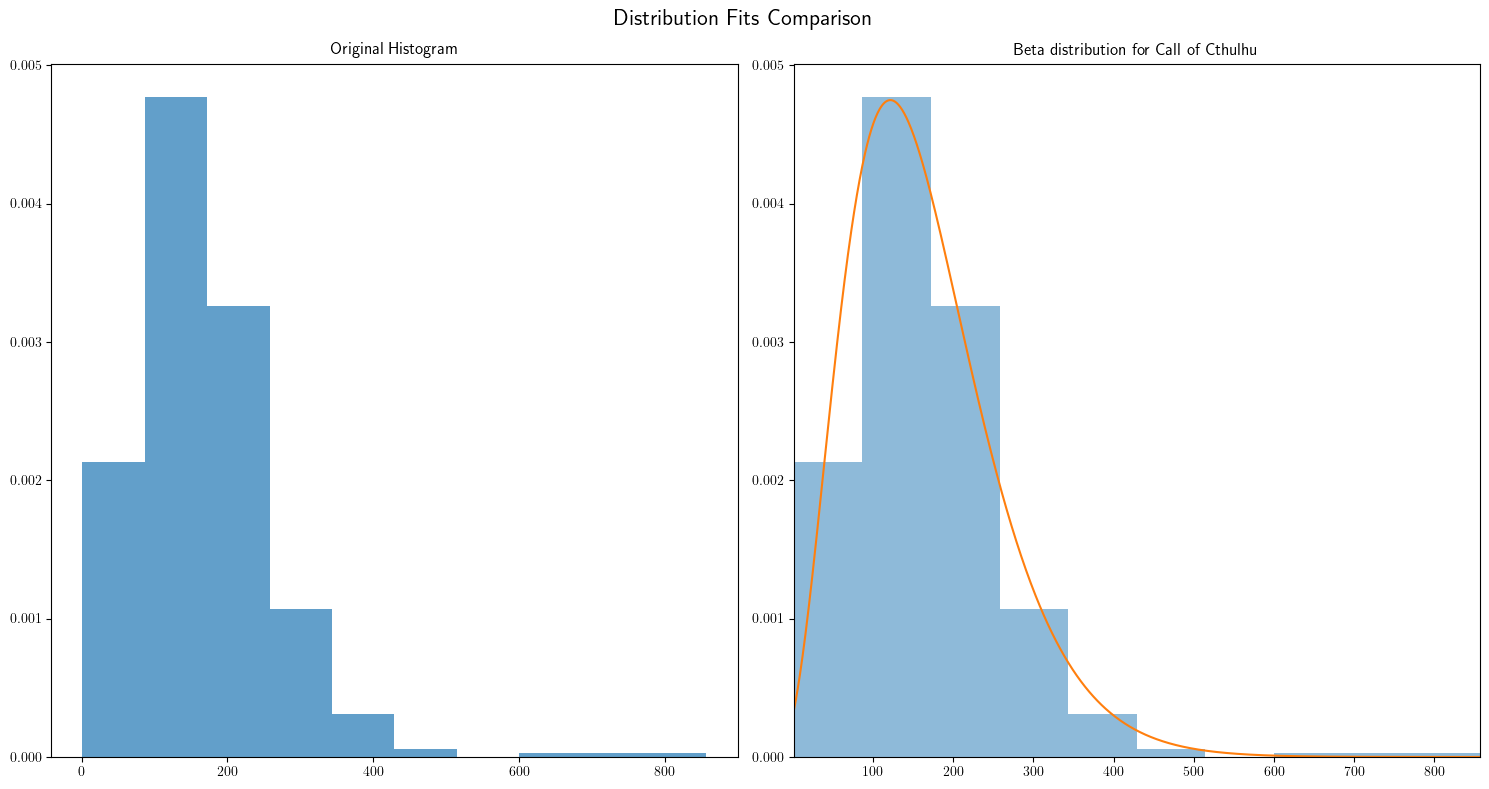

In [516]:
# commum axis
x = np.linspace(min(cthulhu_lens), max(cthulhu_lens), 1000)

# subplots 
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes = axes.flatten()

axes[0].hist(cthulhu_lens, bins=10, density=True, alpha=0.7)
axes[0].set_title('Original Histogram')

axes[1].hist(cthulhu_lens, bins=10, density=True, alpha=0.5)
axes[1].set_title('Beta distribution for Call of Cthulhu')

    
params_cthulhu = stats.beta.fit(cthulhu_lens)
pdf = stats.beta.pdf(x, *params_cthulhu)
    

axes[1].plot(x, pdf)
axes[1].set_xlim(min(cthulhu_lens), max(cthulhu_lens))

plt.suptitle('Distribution Fits Comparison', fontsize=16)
plt.tight_layout()
plt.show()


Using the function $\tt dist\_statistics$ defined on $\tt text\_tools.py$, we get some relevant statiscal informations regarding the distribution for Call of Cthulhu. 

In [517]:
text_tools.dist_statistics(cthulhu_lens)


{'mean': 164.5337,
 'standard_deviation': 97.3004,
 'distribution_mode': 125.0,
 'distribution_median': 150.5,
 'distribution_skew': 2.0318,
 'distribution_kurt': 9.7072}

### 1.1.2 Dunwich Horror

In [518]:
dunwich_lens = [ len(phrase) for phrase in biblio.sentences['dunwich'] ]
#dunwich_lens_filtered = [length for length in dunwich_lens if length > 43]
print(dunwich_lens)

[177, 66, 291, 467, 172, 126, 150, 174, 167, 146, 121, 221, 119, 292, 163, 89, 140, 249, 211, 87, 146, 178, 65, 143, 137, 168, 172, 207, 124, 188, 280, 200, 377, 465, 355, 112, 120, 336, 104, 169, 190, 95, 102, 237, 94, 154, 334, 2, 254, 248, 271, 229, 243, 307, 116, 226, 250, 175, 206, 227, 285, 55, 77, 182, 300, 200, 236, 242, 189, 302, 140, 195, 171, 251, 189, 198, 143, 126, 132, 204, 154, 147, 224, 133, 191, 304, 220, 326, 112, 3, 97, 262, 227, 160, 94, 183, 187, 441, 83, 116, 92, 90, 179, 156, 162, 173, 357, 101, 134, 248, 98, 65, 146, 140, 166, 102, 152, 210, 116, 102, 198, 157, 178, 201, 390, 65, 88, 195, 215, 87, 146, 162, 2, 185, 236, 212, 203, 182, 273, 114, 162, 256, 59, 61, 68, 45, 82, 192, 123, 222, 232, 150, 162, 32, 36, 140, 36, 26, 397, 100, 107, 73, 111, 140, 215, 334, 138, 167, 380, 74, 278, 160, 76, 57, 112, 114, 116, 166, 95, 136, 96, 1, 105, 417, 358, 255, 322, 103, 16, 17, 93, 237, 232, 193, 62, 104, 26, 23, 47, 49, 90, 122, 294, 121, 82, 95, 334, 52, 112, 60, 77,

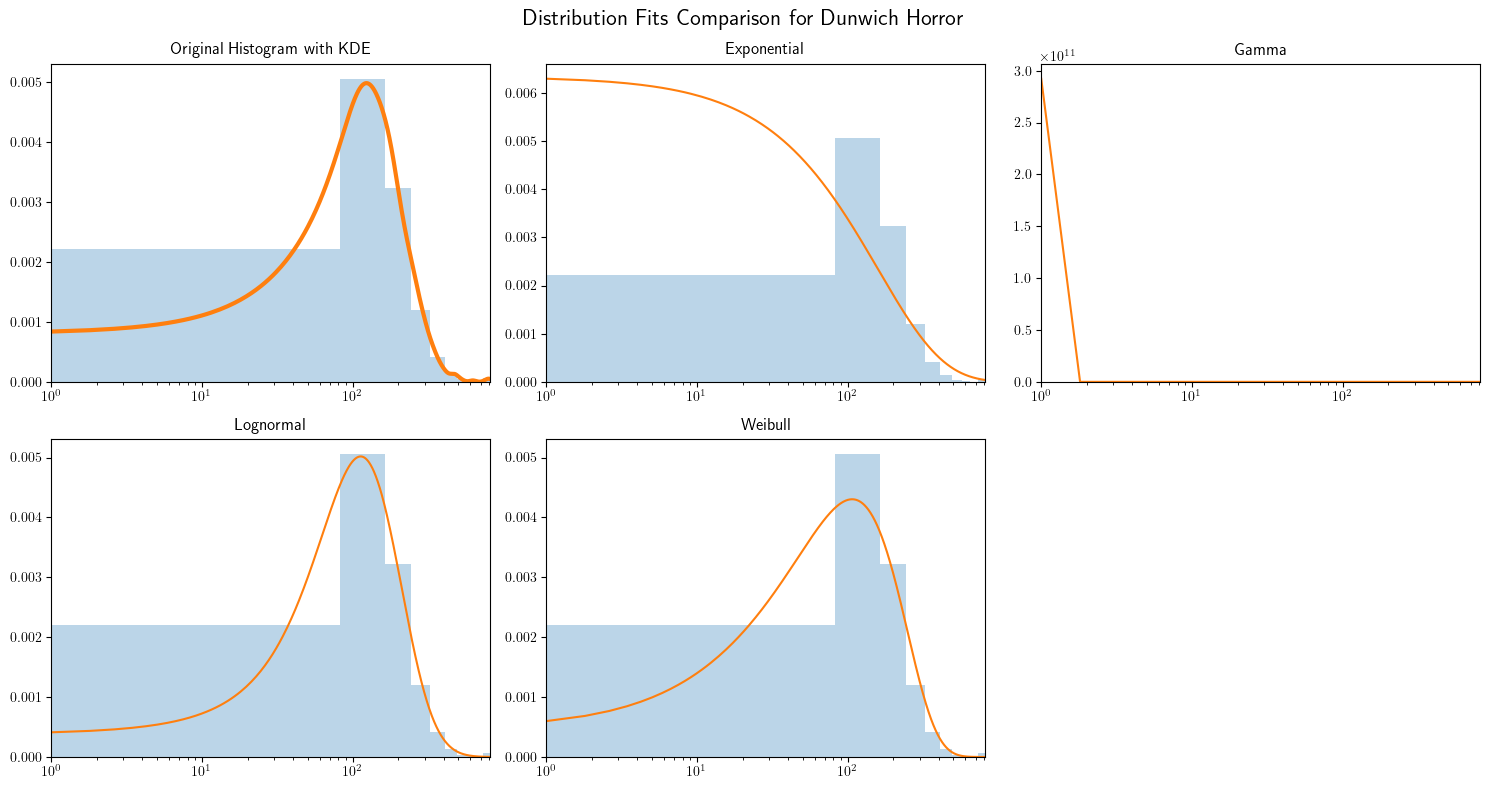

In [533]:
distributions = {
    'Exponential': stats.expon.fit(dunwich_lens),
    'Gamma': stats.gamma.fit(dunwich_lens),
    'Lognormal': stats.lognorm.fit(dunwich_lens),
    'Weibull': stats.weibull_min.fit(dunwich_lens)
}

# eixo comum
x = np.linspace(min(dunwich_lens), max(dunwich_lens), 1000)
kde = stats.gaussian_kde(dunwich_lens)

# subplots (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

axes[0].hist(dunwich_lens, bins=10, density=True, alpha=0.3)
axes[0].plot(x, kde(x), label='KDE', linewidth=3)
axes[0].set_title('Original Histogram with KDE')

for i, (name, params) in enumerate(distributions.items(), start =1):
    ax = axes[i]

    axes[i].hist(dunwich_lens, bins=10, density=True, alpha=0.3)

    if name == 'Weibull':
        dist = stats.weibull_min
    elif name == 'Lognormal':
        dist = stats.lognorm
    elif name == 'Gamma':
        dist = stats.gamma
    else:
        dist = stats.expon
    
    ax.plot(x, dist.pdf(x, *params), label=name)
    ax.set_title(name)

# ajuste geral
for ax in axes:
    ax.set_xlim(min(dunwich_lens), max(dunwich_lens))
    ax.set_xscale('log')
axes[5].set_visible(False)

plt.suptitle('Distribution Fits Comparison for Dunwich Horror', fontsize=16)
plt.tight_layout()
plt.show()

### 1.1.3 The Alchemist

In [520]:
alchemist_lens = [ len(phrase) for phrase in biblio.sentences['alchemist'] ]
#alchemist_lens_filtered = [length for length in alchemist_lens if length > 43]
print(alchemist_lens)

[192, 216, 213, 177, 46, 524, 197, 183, 159, 23, 168, 190, 298, 145, 237, 304, 95, 108, 134, 502, 104, 357, 183, 105, 158, 142, 259, 195, 151, 83, 186, 210, 130, 173, 173, 184, 140, 129, 450, 131, 141, 314, 248, 287, 114, 158, 228, 84, 405, 40, 116, 74, 97, 260, 264, 58, 95, 166, 185, 77, 189, 148, 86, 343, 143, 186, 219, 110, 227, 113, 99, 166, 229, 90, 50, 188, 128, 56, 80, 101, 231, 137, 145, 108, 116, 240, 217, 558, 454, 379, 186, 161, 174, 178, 562, 123, 92, 32, 81, 60, 108, 116, 124, 107, 195, 74, 156, 71, 130, 70, 165, 120, 578]


In [521]:
print(min(alchemist_lens))

23


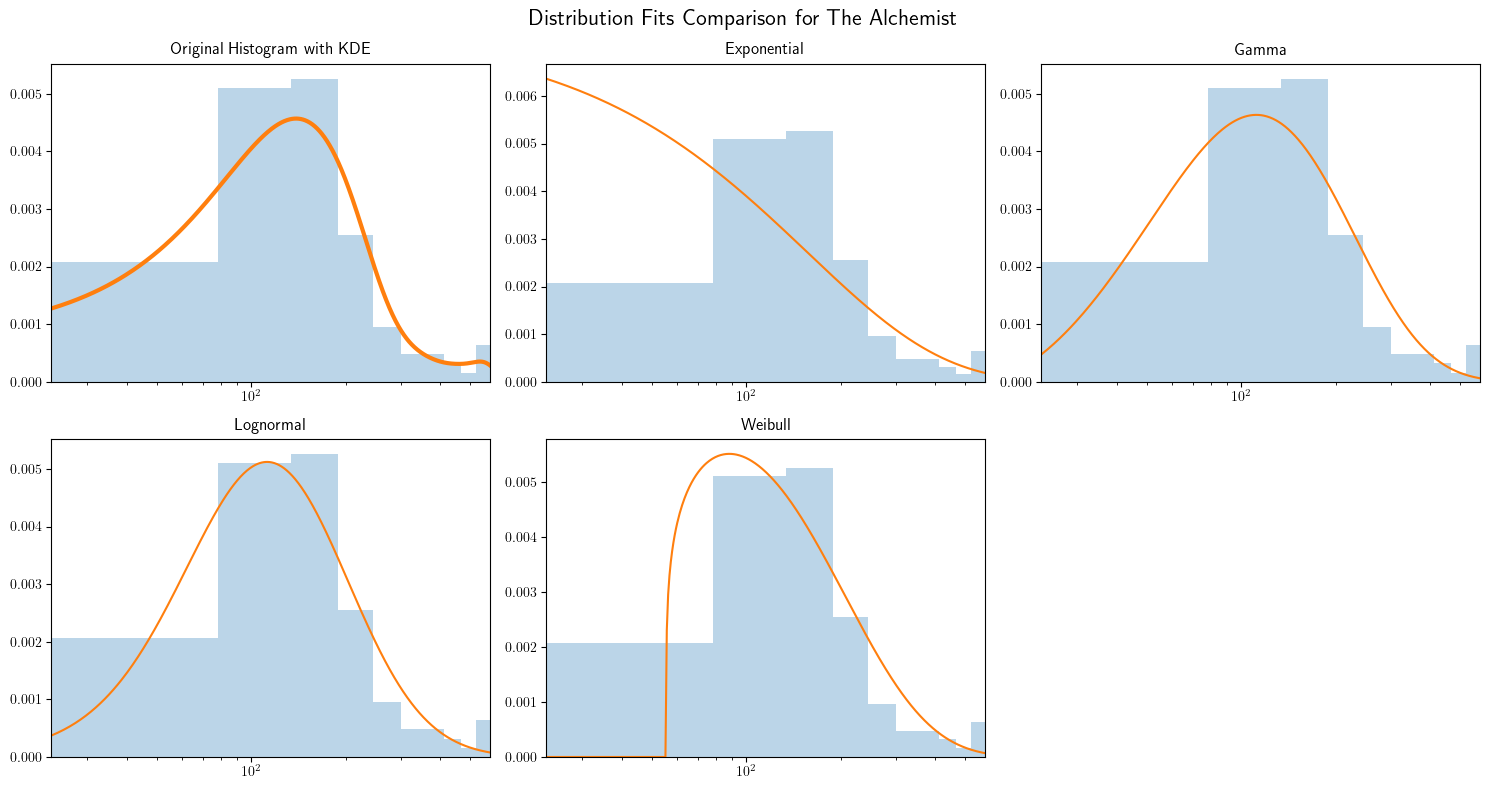

In [534]:
distributions = {
    'Exponential': stats.expon.fit(alchemist_lens),
    'Gamma': stats.gamma.fit(alchemist_lens),
    'Lognormal': stats.lognorm.fit(alchemist_lens),
    'Weibull': stats.weibull_min.fit(alchemist_lens)
}

# eixo comum
x = np.linspace(min(alchemist_lens), max(alchemist_lens), 1000)
kde = stats.gaussian_kde(alchemist_lens)

# subplots (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

axes[0].hist(alchemist_lens, bins=10, density=True, alpha=0.3)
axes[0].plot(x, kde(x), label='KDE', linewidth=3)
axes[0].set_title('Original Histogram with KDE')

for i, (name, params) in enumerate(distributions.items(), start =1):
    ax = axes[i]

    axes[i].hist(alchemist_lens, bins=10, density=True, alpha=0.3)

    if name == 'Weibull':
        dist = stats.weibull_min
    elif name == 'Lognormal':
        dist = stats.lognorm
    elif name == 'Gamma':
        dist = stats.gamma
    else:
        dist = stats.expon
    
    ax.plot(x, dist.pdf(x, *params), label=name)
    ax.set_title(name)

# ajuste geral
for ax in axes:
    ax.set_xlim(min(alchemist_lens), max(alchemist_lens))
    ax.set_xscale('log')
axes[5].set_visible(False)

plt.suptitle('Distribution Fits Comparison for The Alchemist', fontsize=16)
plt.tight_layout()
plt.show()

In [538]:
print(f'cthulhu lenght: ', len(cthulhu_lens))
print(f'dunwich lenght: ', len(dunwich_lens))
print(f'alchemist lenght: ', len(alchemist_lens))

cthulhu lenght:  416
dunwich lenght:  621
alchemist lenght:  113


#### 1.1.1.1 Sketch 

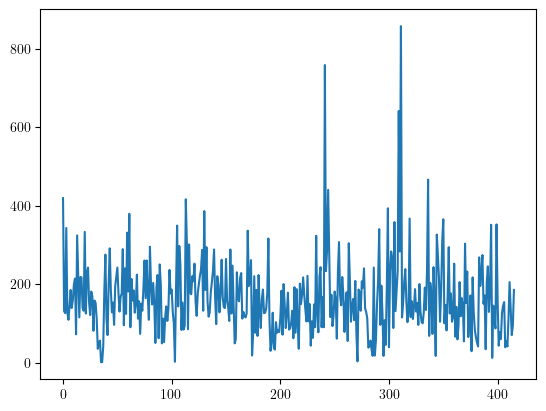

In [523]:
plt.plot(cthulhu_lens)

In [524]:
plt.plot(cthulhu_lens_filtered)

NameError: name 'cthulhu_lens_filtered' is not defined

In [ ]:
cthulhu_df = pd.DataFrame(cthulhu_lens)

In [ ]:
cthulhu_df.head()

,0
0,419
1,131
2,126
3,343
4,127


In [ ]:
print((len(cthulhu_lens)))

416


In [ ]:
print(max(cthulhu_lens))

857


(0.0, 400.0)

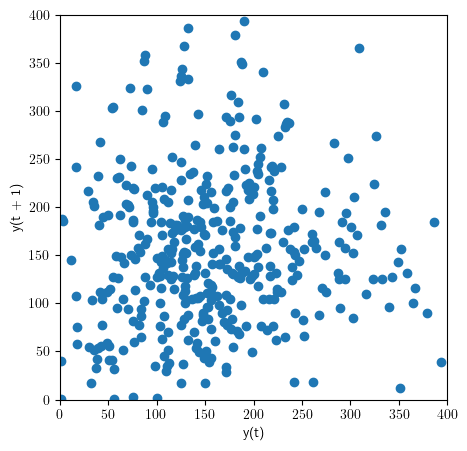

In [ ]:
plt.figure(figsize=(5,5))
pd.plotting.lag_plot(cthulhu_df, lag=1)
plt.xlim(0,400)
plt.ylim(0,400)

In [ ]:
# for lag_value in range(1,40):
#     print( 'Lag = '  + str(lag_value) )
#     plt.figure(figsize=(5,5))
#     pd.plotting.lag_plot(cthulhu_df, lag=lag_value)
#     plt.xlim(0,400)
#     plt.ylim(0,400)
#     plt.show()
#     print('_______________________________________________________________________')

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf


In [ ]:
lag_list = list(range(1,400))

<Figure size 500x2000 with 0 Axes>

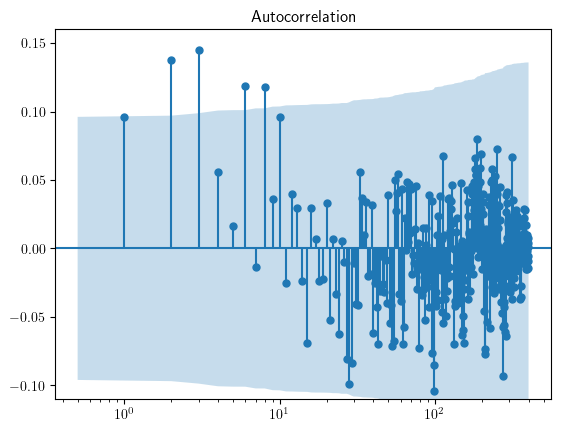

In [ ]:
plt.figure(figsize = (5,20))
plot_acf(cthulhu_df, lags = lag_list)
plt.xscale('log')
plt.ylim(-0.11, 0.16)
plt.show()


In [ ]:
result = np.correlate(cthulhu_lens, cthulhu_lens, mode = 'full')

(4000000.0, 15000000.0)

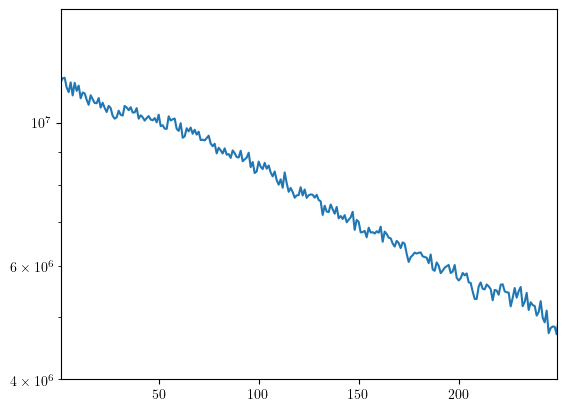

In [ ]:
x_interval = list(range(1,250))

plt.plot(result[result.size // 2:])
plt.yscale('log')
plt.xlim(x_interval[0],x_interval[-1])
plt.ylim(4e6,1.5e7)
#plt.xscale('log')

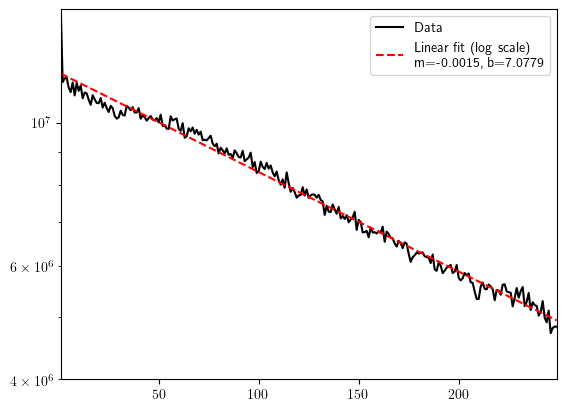

In [ ]:
import numpy as np

x_interval = list(range(1, 250))
y_data = result[result.size // 2:][:249]

# Linear fit in log space
log_y = np.log10(y_data)
coeffs = np.polyfit(x_interval, log_y, 1)
fit_line = np.power(10, np.polyval(coeffs, x_interval))

plt.figure()
plt.plot(x_interval, y_data, 'k-', label='Data')
plt.plot(x_interval, fit_line, 'r--', label=f'Linear fit (log scale)\nm={coeffs[0]:.4f}, b={coeffs[1]:.4f}')
plt.yscale('log')
plt.xlim(x_interval[0], x_interval[-1])
plt.ylim(4e6, 1.5e7)
plt.legend()
plt.show()

(100000.0, 15000000.0)

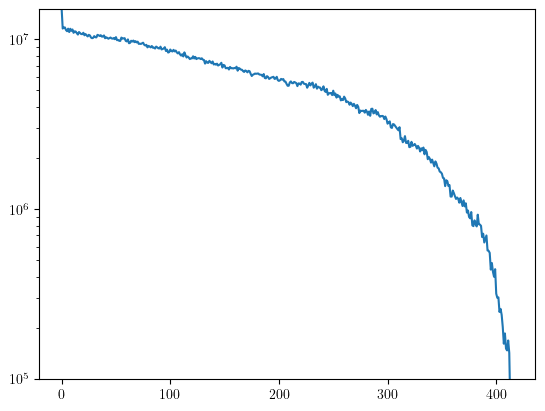

In [ ]:
x_interval = list(range(1,250))

plt.plot(result[result.size // 2:])
plt.yscale('log')
#plt.xlim(x_interval[0],x_interval[-1])
plt.ylim(1e5,1.5e7)

In [ ]:
result_new = result[result.size // 2:]
lag = list(range(0,416))
lag_array = np.array(lag)
z = np.exp(-lag_array)

In [ ]:
len(result_new)

416

In [ ]:
len(lag_array)

416

In [ ]:
alpha, lnA = np.polyfit(np.log(z),np.log(result_new), deg = 1)
# returns (alpha, ln(A))

In [ ]:
print(alpha)
print(lnA)

0.007363420195470758
16.756348053469655


In [ ]:
cor_anal = np.exp(lnA)*(z**(alpha))


In [ ]:
linear_fit = np.polyfit(lag_array,result_new, deg = 1)
print(linear_fit)


[  -27483.11727519 11351851.41152463]


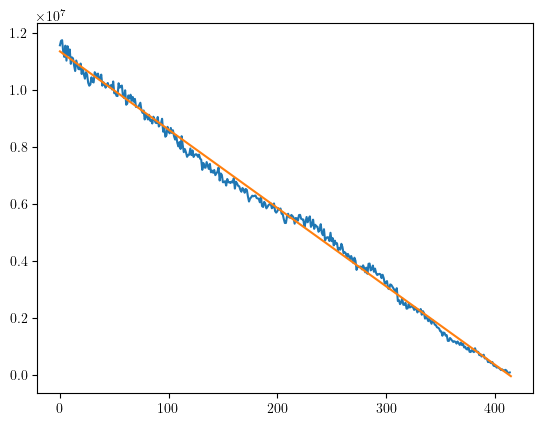

In [ ]:
#plt.plot(cor_anal)
plt.plot(result_new[1:])
plt.plot(lag_array, linear_fit[1]+linear_fit[0]*lag_array)
#plt.yscale('log')